In [1]:
import ssl

ssl._create_default_https_context = ssl._create_stdlib_context

In [2]:
from pathlib import Path

import earthkit.plots
import humanize
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [3]:
# Retrieve the data
ERA5 = xr.open_dataset(
    "/Users/junityre/cra5/data/ERA5/2024/2024-06-01T00:00:00_pressure.nc"
)
ERA5_all_nbytes = ERA5.nbytes
ERA5 = ERA5[["u", "v"]].sel(valid_time="2024-06-01T00:00:00")

In [4]:
CRA5 = ERA5.copy(
    deep=True,
    data=dict(
        u=np.load("/Users/junityre/cra5/data/cra5/2024/2024-06-01T00:00:00_u.npy"),
        v=np.load("/Users/junityre/cra5/data/cra5/2024/2024-06-01T00:00:00_v.npy"),
    ),
)
CRA5_all_nbytes = len(
    Path("/Users/junityre/cra5/data/cra5/2024/2024-06-01T00:00:00.bin").read_bytes()
)

In [5]:
ERA5 = ERA5.sel(pressure_level=500)
ERA5_nbytes = ERA5.nbytes

CRA5 = CRA5.sel(pressure_level=500)
# simple assumption: equal contributions
CRA5_nbytes = CRA5_all_nbytes * (ERA5_nbytes / ERA5_all_nbytes)

In [6]:
CRA5_cr = ERA5_nbytes / CRA5_nbytes
CRA5_cr

452.4558941061463

In [7]:
def compute_vorticity(ERA5: xr.Dataset) -> xr.DataArray:
    # reimplementation of np.deg2rad that matches the safeguards QoI
    def deg2rad(a: np.ndarray) -> np.ndarray:
        # np.deg2rad(a) = a * a.dtype.type(np.pi / 180)
        return a * a.dtype.type(np.pi) / a.dtype.type(180)

    earth_radius = 6371000  # [m], globally averaged

    # computing the derivative with a finite difference requires extending the
    #  data domain and tricking xarray for the coordinates
    # e.g. the data needs to be wrapped along the longitude axis,
    #  but the longitude coordinate needs to be extended with odd reflection
    #  ([0, 0.25, ..., 359.75, 360] -> [-0.25, 0, 0.25, ..., 359.75, 360, 360.25])
    #  since xarray cannot handle differentiating along a proper periodic axis
    # along the latitude axis, xr.differentiate -> np.gradient falls back to
    #  forward/backwards differences at the boundaries (poles)
    ERA5_wrapped = ERA5.pad(longitude=1, mode="wrap").assign_coords(
        longitude=ERA5.longitude.pad(longitude=1, mode="reflect", reflect_type="odd"),
    )

    # compute the vorticity
    ERA5_dUdTheta = (
        ERA5_wrapped["u"]
        * np.cos(deg2rad(ERA5_wrapped["latitude"].astype(ERA5_wrapped["u"].dtype)))
    ).differentiate("latitude")
    ERA5_dVdPhi = ERA5_wrapped["v"].differentiate("longitude")

    ERA5_VOR = (ERA5_dVdPhi - ERA5_dUdTheta) / (
        earth_radius
        * np.cos(deg2rad(ERA5_wrapped["latitude"].astype(ERA5_wrapped["u"].dtype)))
    )

    # remove the padding to extract just the valid values
    ERA5_VOR = ERA5_VOR.sel(longitude=slice(0, 359.9))
    ERA5_VOR.attrs.update(long_name="vorticity", units="s**-1")

    return ERA5_VOR

In [8]:
ERA5_VOR = compute_vorticity(ERA5)

In [9]:
def compute_corrections_percentage(my_ERA5: xr.Dataset, orig_ERA5: xr.Dataset) -> float:
    neq = np.sum(my_ERA5 != orig_ERA5)
    return int(neq.u + neq.v) / int(orig_ERA5.u.size + orig_ERA5.v.size)

In [10]:
old_cmap_and_norm = earthkit.plots.styles.colors.cmap_and_norm

In [11]:
def my_cmap_and_norm(colors, levels, normalize=True, extend=None, extend_levels=True):
    return old_cmap_and_norm(colors, levels, normalize, extend, True)


earthkit.plots.styles.colors.cmap_and_norm = my_cmap_and_norm

In [12]:
def plot_vorticity(
    my_ERA5: xr.Dataset,
    cr,
    chart,
    title,
    span,
    vor_eb_abs,
    error=False,
    corr=None,
    my_ERA5_it=None,
    cr_it=None,
):
    import copy

    import dask

    my_ERA5_VOR = compute_vorticity(my_ERA5)

    if error:
        with xr.set_options(keep_attrs=True):
            da = (my_ERA5_VOR - ERA5_VOR).compute()

        err_inf_U = np.amax(np.abs(my_ERA5["u"] - ERA5["u"]))
        err_inf_V = np.amax(np.abs(my_ERA5["v"] - ERA5["v"]))
        err_inf_VOR = np.amax(np.abs(my_ERA5_VOR - ERA5_VOR))
        err_2_VOR = np.sqrt(np.mean(np.square(my_ERA5_VOR - ERA5_VOR)))
        err_v = np.mean(~(np.abs(my_ERA5_VOR - ERA5_VOR) <= vor_eb_abs))

        da.attrs.update(long_name=f"{da.long_name} error")
    else:
        da = my_ERA5_VOR

    # compute the default style that earthkit.maps would apply
    source = earthkit.plots.sources.XarraySource(da)
    style = copy.deepcopy(
        earthkit.plots.styles.auto.guess_style(
            source,
            units=source.units,
        )
    )
    style._levels = earthkit.plots.styles.levels.Levels(np.linspace(-span, span, 22))
    style._legend_kwargs["ticks"] = np.linspace(-span, span, 5)
    style._colors = "coolwarm" if error else "RdBu"

    extend_left = np.nanmin(da) < -span
    extend_right = np.nanmax(da) > span

    extend = {
        (False, False): "neither",
        (True, False): "min",
        (False, True): "max",
        (True, True): "both",
    }[(extend_left, extend_right)]

    if error:
        style._legend_kwargs["extend"] = extend
        chart.pcolormesh(da, style=style, zorder=-12)

        if corr is not None:
            da_hatch = (my_ERA5["u"] == corr["u"]) & (my_ERA5["v"] == corr["v"])

            da_hatch = da_hatch.copy(
                data=dask.array.from_array(da_hatch.values)
                .rechunk(4)
                .map_blocks(lambda x: np.broadcast_to(np.mean(x), x.shape))
                .compute()
            )

            with plt.rc_context(
                {
                    "hatch.color": (1.0, 1.0, 1.0, 0.5),
                    "hatch.linewidth": 0.5,
                }
            ):
                chart.contourf(
                    x=np.broadcast_to(
                        da_hatch.longitude.values.reshape(1, -1), da_hatch.shape
                    ),
                    y=np.broadcast_to(
                        da_hatch.latitude.values.reshape(-1, 1), da_hatch.shape
                    ),
                    z=da_hatch.values,
                    colors=["none"],
                    levels=[-0.5, 0.9, 1.5],
                    hatches=["xxx" if corr is None else "O", None],
                    legend_style=None,
                    zorder=-11,
                )

            if my_ERA5_it is not None:
                with xr.set_options(keep_attrs=True):
                    da_hatch_it = (my_ERA5_it["u"] == corr["u"]) & (
                        my_ERA5_it["v"] == corr["v"]
                    )

                da_hatch_it = da_hatch_it.copy(
                    data=dask.array.from_array(da_hatch_it.values)
                    .rechunk(4)
                    .map_blocks(lambda x: np.broadcast_to(np.mean(x), x.shape))
                    .compute()
                )

                with plt.rc_context(
                    {
                        "hatch.color": (144 / 255, 238 / 255, 144 / 255, 0.5),
                        "hatch.linewidth": 0.25,
                    }
                ):
                    chart.contourf(
                        x=np.broadcast_to(
                            da_hatch_it.longitude.values.reshape(1, -1),
                            da_hatch_it.shape,
                        ),
                        y=np.broadcast_to(
                            da_hatch_it.latitude.values.reshape(-1, 1),
                            da_hatch_it.shape,
                        ),
                        z=da_hatch_it.values,
                        colors=["none"],
                        levels=[-0.5, 0.9, 1.5],
                        hatches=["O", None],
                        legend_style=None,
                        zorder=-11,
                    )
    else:
        chart.quickplot(da, style=style, extend=extend, zorder=-11)

    chart.ax.set_rasterization_zorder(-10)

    if error:
        if my_ERA5_it is not None:
            corr_it = (
                None
                if corr is None
                else compute_corrections_percentage(my_ERA5_it, corr)
            )

        corr = None if corr is None else compute_corrections_percentage(my_ERA5, corr)

        chart.title(
            f"{title}\n"
            + rf"$L_{{{{\infty}}}}(\hat{{{{u}}}})$={err_inf_U:.02}  "
            + rf"$L_{{{{\infty}}}}(\hat{{{{v}}}})$={err_inf_V:.02}  "
            + rf"$L_{{{{\infty}}}}(\hat{{{{\omega}}}})$={err_inf_VOR:.03}  "
            + rf"$L_{{{{2}}}}(\hat{{{{\omega}}}})$={err_2_VOR:.03}"
            + "\n"
            + f"V={0 if err_v == 0 else np.format_float_positional(100 * err_v, precision=1, min_digits=1) + '%'}"
            + (
                ""
                if corr is None
                else (
                    f"  C={0 if corr == 0 else np.format_float_positional(100 * corr, precision=1, min_digits=1) + '%'}"
                    + (
                        ""
                        if corr_it is None
                        else (
                            f" ({0 if corr == 0 else np.format_float_positional(100 * corr_it, precision=1, min_digits=1) + '%'})"
                        )
                    )
                )
            )
        )
    else:
        chart.title(f"{title}\n\n")

    t = chart.ax.text(
        0.95,
        0.9,
        (
            f"x {np.round(cr, 2)}"
            + ("" if cr_it is None else f" (x {np.round(cr_it, 2)})")
        )
        if error
        else humanize.naturalsize(ERA5["u"].nbytes + ERA5["v"].nbytes, binary=True),
        ha="right",
        va="top",
        transform=chart.ax.transAxes,
    )
    t.set_bbox(dict(facecolor="white", alpha=0.75, edgecolor="black"))

    for m in earthkit.plots.schemas.schema.quickmap_subplot_workflow:
        if m != "title":
            getattr(chart, m)()

    for m in earthkit.plots.schemas.schema.quickmap_figure_workflow:
        getattr(chart, m)()

    counts, bins = np.histogram(da.values.flatten(), range=(-span, span), bins=21)
    midpoints = bins[:-1] + np.diff(bins) / 2
    cb = chart.ax.collections[0].colorbar
    if error:
        if extend_left:
            cb._extend_patches[0].set_hatch("xx")
            cb._extend_patches[0].set_ec("white")
        cb.ax.fill_between(
            [-span, -vor_eb_abs], *cb.ax.get_ylim(), hatch="xx", ec="w", fc="none", lw=0
        )
        cb.ax.fill_between(
            [vor_eb_abs, span], *cb.ax.get_ylim(), hatch="xx", ec="w", fc="none", lw=0
        )
        if extend_right:
            cb._extend_patches[-1].set_hatch("xx")
            cb._extend_patches[-1].set_ec("white")
    extend_width = (bins[-1] - bins[-2]) / (bins[-1] - bins[0])
    cax = cb.ax.inset_axes(
        [
            0.0 - extend_width * extend_left,
            1.25,
            1.0 + extend_width * (0 + extend_left + extend_right),
            1.0,
        ]
    )
    cax.bar(
        midpoints,
        height=counts,
        width=(bins[-1] - bins[0]) / len(counts),
        color=cb.cmap(cb.norm(midpoints)),
        **(
            dict(
                hatch=["xx" if np.abs(m) > vor_eb_abs else "" for m in midpoints],
                ec="white",
                lw=0,
            )
            if error
            else dict()
        ),
    )
    if extend_left:
        cax.bar(
            bins[0] - (bins[1] - bins[0]) / 2,
            height=np.sum(da < -span),
            width=(bins[-1] - bins[0]) / len(counts),
            color=cb.cmap(cb.norm(midpoints[0])),
            **(
                dict(
                    hatch="xx",
                    ec="white",
                    lw=0,
                )
                if error
                else dict()
            ),
        )
    if extend_right:
        cax.bar(
            bins[-1] + (bins[-1] - bins[-2]) / 2,
            height=np.sum(da > span),
            width=(bins[-1] - bins[0]) / len(counts),
            color=cb.cmap(cb.norm(midpoints[-1])),
            **(
                dict(
                    hatch="xx",
                    ec="white",
                    lw=0,
                )
                if error
                else dict()
            ),
        )
    q1, q2, q3 = da.quantile([0.25, 0.5, 0.75]).values
    cax.axvline(da.mean().item(), ls=":", ymin=0.1, ymax=0.9, c="w", lw=2)
    cax.axvline(q1, ymin=0.25, ymax=0.75, c="w", lw=2)
    cax.axvline(q2, ymin=0.1, ymax=0.9, c="w", lw=2)
    cax.axvline(q3, ymin=0.25, ymax=0.75, c="w", lw=2)
    cax.axvline(da.mean().item(), ymin=0.1, ymax=0.9, ls=":", c="k", lw=1)
    cax.axvline(q1, ymin=0.25, ymax=0.75, c="k", lw=1)
    cax.axvline(q2, ymin=0.1, ymax=0.9, c="k", lw=1)
    cax.axvline(q3, ymin=0.25, ymax=0.75, c="k", lw=1)
    cax.set_xlim(
        -span - (bins[-1] - bins[-2]) * extend_left,
        span + (bins[-1] - bins[-2]) * extend_right,
    )
    cax.set_xticks([])
    cax.set_yticks([])
    cax.spines[:].set_visible(False)

In [13]:
# Since numcodecs-safeguards only supports single-variable safeguarding, we
# stack the u and v variables into a combined variable.
ERA5_UV = np.stack([ERA5["u"].values, ERA5["v"].values], axis=0)
ERA5.u.dims, ERA5_UV.shape

(('latitude', 'longitude'), (2, 721, 1440))

In [14]:
CRA5_UV = np.stack([CRA5["u"].values, CRA5["v"].values], axis=0)
CRA5.u.dims, CRA5_UV.shape

(('latitude', 'longitude'), (2, 721, 1440))

In [15]:
from compression_safeguards import SafeguardKind

qoi_eb_stencil = SafeguardKind.qoi_eb_stencil.value(
    qoi="""
    V["earth_radius"] = 6371000;  # [m], globally averaged

    # extract u and v from the first stacked dimension
    V["u"] = X[0, I[1], I[2]];
    V["v"] = X[1, I[1], I[2]];
    # convert latitude in degrees to radians
    V["latRad"] = c["lat"] * pi / 180;

    # approximate the spatial derivatives with finite differences
    # (1) along the latitude axis, we need to handle the polar boundary
    V["dUdTheta"] = where(
        abs(c["lat"]) < 90,
        # use central difference where possible
        finite_difference(
            V["u"] * cos(V["latRad"]),
            order=1, accuracy=2, type=0, axis=1,
            grid_centre=c["lat"],
        ),
        # at the poles, use forward/backwards difference
        where(
            c["lat"] == -90,
            finite_difference(
                V["u"] * cos(V["latRad"]),
                order=1, accuracy=1, type=-1, axis=1,
                grid_centre=c["lat"],
            ),
            finite_difference(
                V["u"] * cos(V["latRad"]),
                order=1, accuracy=1, type=+1, axis=1,
                grid_centre=c["lat"],
            ),
        ),
    );
    # (2) along the longitude axis, we handle the 360 degree periodic boundary
    V["dVdPhi"] = finite_difference(
        V["v"],
        order=1, accuracy=2, type=0, axis=2,
        grid_centre=c["lon"], grid_period=360,
    );

    # compute the vorticity
    return (V["dVdPhi"] - V["dUdTheta"]) / (
        V["earth_radius"] * cos(V["latRad"])
    );
    """,
    type="abs",
    eb=1e-6,
    neighbourhood=[
        # [u, v]: stacked variables
        dict(axis=0, before=0, after=1, boundary="valid"),
        # latitude: edge boundary is good enough (since we ensure in the QoI
        #           that the edge-extended values are not used)
        dict(axis=1, before=1, after=1, boundary="edge"),
        # longitude: wrapping boundary
        dict(axis=2, before=1, after=1, boundary="wrap"),
    ],
)

In [16]:
import numcodecs_safeguards

lossless = numcodecs_safeguards.lossless._default_lossless_for_safeguards()
lossless

PickBestCodec(CodecStack(TokenizeCodec(), BitmapIndexCodec(), TypedByteShuffleCodec(), FramedCodecStack(Zstd(level=3))), CodecStack(BinaryDeltaCodec(), TokenizeCodec(), BitmapIndexCodec(), TypedByteShuffleCodec(), FramedCodecStack(Zstd(level=3))))

In [17]:
from compression_safeguards import Safeguards
from compression_safeguards.utils.bindings import Bindings

sg = Safeguards(safeguards=[qoi_eb_stencil])

late_bound = Bindings(
    lat=ERA5.latitude.values.reshape(1, -1, 1),
    lon=ERA5.longitude.values.reshape(1, 1, -1),
)

CRA5_UV_correction = sg.compute_correction(ERA5_UV, CRA5_UV, late_bound=late_bound)

CRA5_UV_correction_compressed = lossless.encode(CRA5_UV_correction)
CRA5_sg_cr = ERA5_UV.nbytes / (
    CRA5_nbytes + np.asarray(CRA5_UV_correction_compressed).nbytes
)

CRA5_UV_sg = sg.apply_correction(CRA5_UV, CRA5_UV_correction)
CRA5_sg = ERA5.copy(data=dict(u=CRA5_UV_sg[0], v=CRA5_UV_sg[1]))

/Users/junityre/numcodecs-safeguards/src/compression_safeguards/safeguards/_qois/bound.py:262: QuantityOfInterestRuntimeWarning: data bounds required excessive nudging
  warn(
/Users/junityre/numcodecs-safeguards/src/compression_safeguards/safeguards/_qois/bound.py:237: QuantityOfInterestRuntimeWarning: guaranteed data bounds do not meet the expression bounds
  warn(


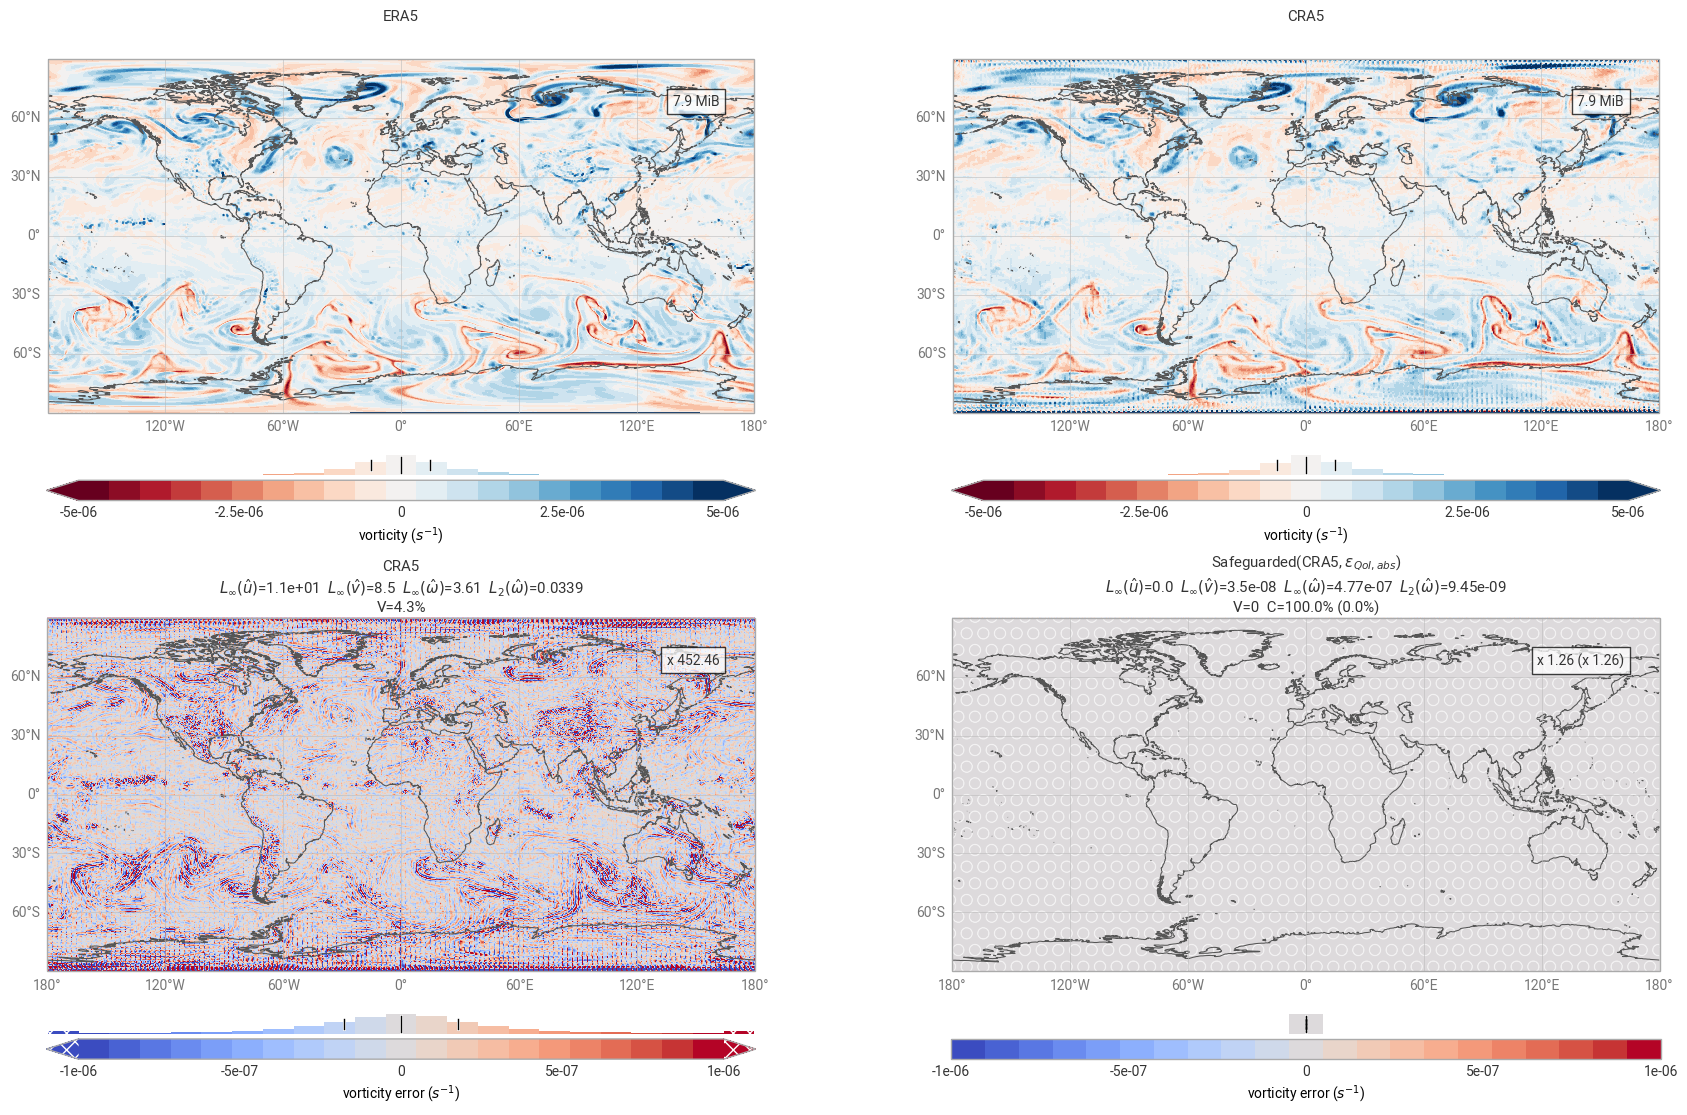

In [18]:
fig = earthkit.plots.Figure(
    size=(18, 11),
    rows=2,
    columns=2,
)

plot_vorticity(
    ERA5,
    1.0,
    fig.add_map(0, 0),
    "ERA5",
    span=5e-6,
    vor_eb_abs=1e-6,
)
plot_vorticity(
    CRA5,
    1.0,
    fig.add_map(0, 1),
    "CRA5",
    span=5e-6,
    vor_eb_abs=1e-6,
)

plot_vorticity(
    CRA5,
    CRA5_cr,
    fig.add_map(1, 0),
    r"CRA5",
    span=1e-6,
    vor_eb_abs=1e-6,
    error=True,
)
plot_vorticity(
    CRA5_sg,
    CRA5_sg_cr,
    fig.add_map(1, 1),
    r"Safeguarded(CRA5, $\epsilon_{{QoI,abs}}$)",
    span=1e-6,
    vor_eb_abs=1e-6,
    error=True,
    corr=CRA5,
    my_ERA5_it=CRA5,
    cr_it=CRA5_sg_cr,
)

fig.show()